# Design a GridWorld environment 
navigation in a 2D space where there are some states to avoid (holes where agent falls) 

🎯 Skill: Navigate efficiently to a target location

👀 Information: Agent position and target position on a grid

🎮 Actions: Move up, down, left, or right

🏆 Success: Reach the target in minimum steps

⏰ End: When agent reaches target (or optional time limit)

In [1]:
#%pip install typing

In [1]:
import gymnasium as gym
import numpy as np
from typing import Optional

In [3]:
class GridWorldEnv(gym.Env):
    def __init__(self, size: int = 5, render_mode: str = None):
        self.size = size #size of the world defined
        self.render_mode = render_mode
        # the inizialization will be reset randomly with the function reset()
        self.agent_location = np.array([-1,-1], dtype=np.int32)
        self.target_location = np.array([-1,-1], dtype=np.int32)

        self.observation_space = gym.spaces.Dict(
            {
                "agent": gym.spaces.Box(0, size-1, shape=(2,), dtype=int), # [x,y] coordinates
                "target": gym.spaces.Box(0, size-1, shape=(2,), dtype=int), 
            }
        )

        self.action_space = gym.spaces.Discrete(4) #4 directions are available

        self.action_to_direction = {
            0: np.array([0, 1]),   # Move right (column + 1)
            1: np.array([-1, 0]),  # Move up (row - 1)
            2: np.array([0, -1]),  # Move left (column - 1)
            3: np.array([1, 0]),   # Move down (row + 1)
        }
    
    def get_obs(self):
        return {"agent": self.agent_location, "target":  self.target_location}
    
    def get_info(self):
        return {
            "distance": np.linalg.norm(
                self.agent_location - self.target_location, ord=1
            )
        }
    def reset(self, seed: Optional[int] = None, options:Optional[dict] = None):

        super().reset(seed=seed) #important to seed the random number generator

        self.agent_location = self.np_random.integers(0, self.size, size=2, dtype=int)

        self.target_location = self.agent_location
        while np.array_equal(self.target_location, self.agent_location):
            self.target_location = self.np_random.integers(
                0, self.size, size=2, dtype=int
            )
        
        observation = self.get_obs()
        info = self.get_info()

        return observation, info
    
    def step(self, action):
        
        direction = self.action_to_direction[action]

        self.agent_location = np.clip(self.agent_location + direction, 0, self.size - 1)

        terminated = np.array_equal(self.agent_location, self.target_location)
        truncated = False ## in this case

        distance = np.linalg.norm(self.agent_location - self.target_location, ord=1)
        reward = 1 if terminated else -0.05 * distance

        observation = self.get_obs()
        info = self.get_info()

        return observation, reward, terminated, truncated, info

    def render(self): #Advanced feature for rendering
        """Render the environment for human viewing."""
        if self.render_mode == "human" or 1==1:
            # Print a simple ASCII representation
            for y in range(self.size - 1, -1, -1):  # Top to bottom
                row = ""
                for x in range(self.size):
                    if np.array_equal([x, y], self.agent_location):
                      row += "A "  # Agent
                    elif np.array_equal([x, y], self.target_location):
                        row += "T "  # Target
                    else:
                        row += ". "  # Empty
                print(row)
            print()


Register the environment to call it with gym.make()

In [4]:
gym.register(
    id = "gymnasium_env/GridWorld-v0",
    entry_point = GridWorldEnv,
    max_episode_steps = 500, #prevent infinite episodes
)

Use the environment created with personalization of the parameters

In [5]:
env = gym.make("gymnasium_env/GridWorld-v0", size=10) #Grid World 10*10


In [6]:
# This will catch many common issues
from gymnasium.utils.env_checker import check_env

try:
    check_env(env)
    print("Environment passes all checks!")
except Exception as e:
    print(f"Environment has issues: {e}")

Environment passes all checks!


c:\Users\39324\anaconda3\envs\naml_libraries\lib\site-packages\gymnasium\utils\env_checker.py:384: UserWarning: WARN: The environment (<TimeLimit<OrderEnforcing<PassiveEnvChecker<GridWorldEnv<gymnasium_env/GridWorld-v0>>>>>) is different from the unwrapped version (<GridWorldEnv<gymnasium_env/GridWorld-v0>>). This could effect the environment checker as the environment most likely has a wrapper applied to it. We recommend using the raw environment for `check_env` using `env.unwrapped`.
  logger.warn(


Manual testing of known actions

In [7]:
# Test specific action sequences to verify behavior
env = gym.make("gymnasium_env/GridWorld-v0")
obs, info = env.reset(seed=42)  # Use seed for reproducible testing

print(f"Starting position - Agent: {obs['agent']}, Target: {obs['target']}")

# Test each action type
actions = [2, 3, 3, 3]  # left, down, down, down
for action in actions:
    old_pos = obs['agent'].copy()
    obs, reward, terminated, truncated, info = env.step(action)
    new_pos = obs['agent']
    print(f"Action {action}: {old_pos} -> {new_pos}, reward={reward}")
    env.render()

Starting position - Agent: [0 3], Target: [3 2]
Action 2: [0 3] -> [0 2], reward=-0.15000000000000002
. . . . . 
. . . . . 
A . . T . 
. . . . . 
. . . . . 

Action 3: [0 2] -> [1 2], reward=-0.1
. . . . . 
. . . . . 
. A . T . 
. . . . . 
. . . . . 

Action 3: [1 2] -> [2 2], reward=-0.05
. . . . . 
. . . . . 
. . A T . 
. . . . . 
. . . . . 

Action 3: [2 2] -> [3 2], reward=1
. . . . . 
. . . . . 
. . . A . 
. . . . . 
. . . . . 



## CREATE AN AGENT FOR THE GRID ENVIRONMENT

- Q-learning
- epsilon greedy startegy
- constant learning rate and epsilon


In [8]:
from collections import defaultdict

In [9]:
class GridWorldAgent:
    def __init__(
            self,
            env: gym.Env,
            learning_rate: float,
            initial_epsilon: float,
            epsilon_decay:float,
            final_epsilon: float,
            discount_factor: float = 0.95,
    ):
        self.env = env
        self.learning_rate = learning_rate
        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon
        self.discount_factor = discount_factor

        self.q_values = defaultdict(lambda: np.zeros(env.action_space.n))
        self.training_error = []
    
    def state_to_key(self, obs: dict[str, np.ndarray]) -> tuple:
        return (
            tuple(obs["agent"]),
            tuple(obs["target"])
        )
    
    def get_action(self, obs: dict[str, np.ndarray]) -> int:
        state = self.state_to_key(obs) #make the observation hashable

        if np.random.random()< self.epsilon:
            return self.env.action_space.sample()
        else:
            return int(np.argmax(self.q_values[state]))
    
    def update(
            self,
            obs: dict[str, np.ndarray],
            action: int,
            reward: float,
            terminated: bool,
            next_obs: dict[str, np.ndarray],
    ):
        state = self.state_to_key(obs)
        next_state = self.state_to_key(next_obs)
        future_q_value = (not terminated) * np.max(self.q_values[next_state])
        target = reward + self.discount_factor * future_q_value
        temporal_difference = target - self.q_values[state][action]
        
        self.q_values[state][action] += self.learning_rate * temporal_difference

        self.training_error.append(temporal_difference)

    def decay_epsilon(self):
        """Reduce exploration rate after each episode."""
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)
    


In [10]:
learning_rate = 0.01
n_episodes = 50000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.01

# using the gridWorld environment
env = gym.make("gymnasium_env/GridWorld-v0", render_mode="human")
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)

agent = GridWorldAgent(
    env = env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

c:\Users\39324\anaconda3\envs\naml_libraries\lib\site-packages\gymnasium\envs\registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='human' that is not in the possible render_modes ([]).
  logger.warn(


In [11]:
from tqdm import tqdm

for episode in tqdm(range(n_episodes)):
    # start a new hand
    obs, info = env.reset()
    done = False

    #Play a complete episode
    while not done:
        action = agent.get_action(obs) #follows the eps-greedy action selection strategy
        next_obs, reward, terminated, truncated, info = env.step(action)
        # nb: the observation are in this implementation like the state of the agent, he observe its state   

        agent.update(obs, action, reward, terminated, next_obs) #agent learn from the results of the environment
        obs = next_obs 
        done = terminated or truncated


    agent.decay_epsilon()

100%|██████████| 50000/50000 [00:29<00:00, 1718.25it/s]


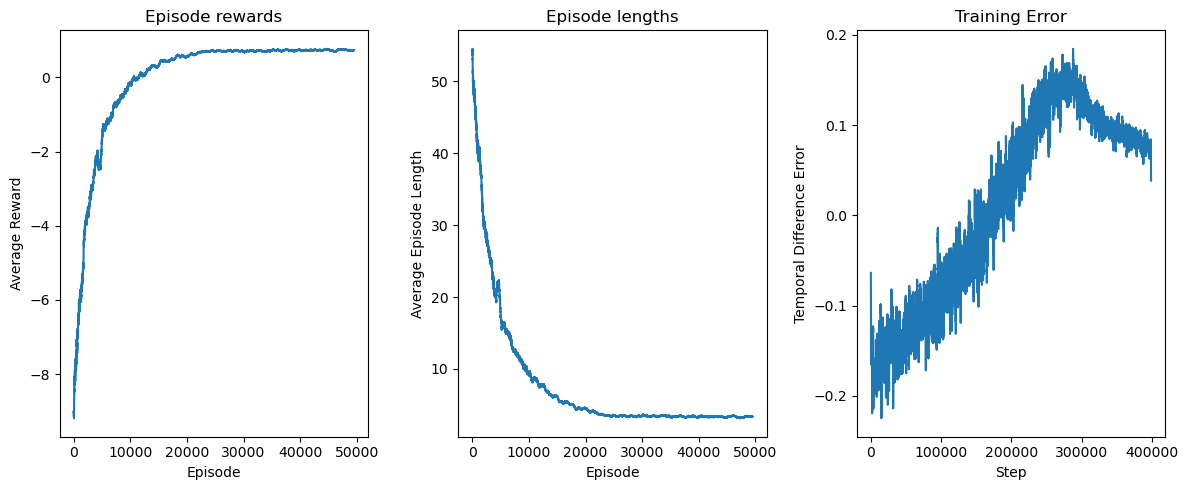

In [12]:
from matplotlib import pyplot as plt

def get_moving_avgs(arr, window, convolution_mode):
    """Compute moving average to smooth noisy data."""
    return np.convolve(
        np.array(arr).flatten(),
        np.ones(window),
        mode=convolution_mode
    ) / window

# Smooth over a 500-episode window
rolling_length = 500
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))

# Episode rewards (win/loss performance)
axs[0].set_title("Episode rewards")
reward_moving_average = get_moving_avgs(
    env.return_queue,
    rolling_length,
    "valid"
)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)
axs[0].set_ylabel("Average Reward")
axs[0].set_xlabel("Episode")

# Episode lengths (how many actions per hand)
axs[1].set_title("Episode lengths")
length_moving_average = get_moving_avgs(
    env.length_queue,
    rolling_length,
    "valid"
)
axs[1].plot(range(len(length_moving_average)), length_moving_average)
axs[1].set_ylabel("Average Episode Length")
axs[1].set_xlabel("Episode")

# Training error (how much we're still learning)
axs[2].set_title("Training Error")
training_error_moving_average = get_moving_avgs(
    agent.training_error,
    rolling_length,
    "same"
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
axs[2].set_ylabel("Temporal Difference Error")
axs[2].set_xlabel("Step")

plt.tight_layout()
plt.show()

In [13]:
# Test the trained agent
def test_agent(agent, env, num_episodes=1000):
    """Test agent performance without learning or exploration."""
    total_rewards = []
    # Temporarily disable exploration for testing
    old_epsilon = agent.epsilon
    agent.epsilon = 0.0  # Pure exploitation

    for _ in range(num_episodes): #number of episodes = game the agent plays
        obs, info = env.reset()
        episode_reward = 0
        done = False
        path = [tuple(map(int, obs["agent"]))]


        while not done:  # run an episode
            action = agent.get_action(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            done = terminated or truncated
            path.append(tuple(map(int, obs["agent"])))

        path_str = " -> ".join([f"({r},{c})" for r, c in path])
        target_clean = tuple(map(int, env.unwrapped.target_location))
        print(f"🎯 Target: {target_clean} | 🛤️  Percorso: {path_str}")
        total_rewards.append(episode_reward)
        path = []

    # Restore original epsilon
    agent.epsilon = old_epsilon

    win_rate = np.mean(np.array(total_rewards) > 0)
    average_reward = np.mean(total_rewards)

    print(f"Test Results over {num_episodes} episodes:")
    print(f"Win Rate: {win_rate:.1%}")
    print(f"Average Reward: {average_reward:.3f}")
    print(f"Standard Deviation: {np.std(total_rewards):.3f}")

# Test your agent
test_agent(agent, env)

🎯 Target: (3, 3) | 🛤️  Percorso: (1,2) -> (2,2) -> (3,2) -> (3,3)
🎯 Target: (3, 2) | 🛤️  Percorso: (0,1) -> (0,2) -> (1,2) -> (2,2) -> (3,2)
🎯 Target: (2, 1) | 🛤️  Percorso: (3,1) -> (2,1)
🎯 Target: (1, 1) | 🛤️  Percorso: (3,1) -> (2,1) -> (1,1)
🎯 Target: (3, 4) | 🛤️  Percorso: (3,3) -> (3,4)
🎯 Target: (2, 4) | 🛤️  Percorso: (4,2) -> (3,2) -> (2,2) -> (2,3) -> (2,4)
🎯 Target: (1, 4) | 🛤️  Percorso: (4,4) -> (3,4) -> (2,4) -> (1,4)
🎯 Target: (4, 4) | 🛤️  Percorso: (2,1) -> (2,2) -> (2,3) -> (3,3) -> (3,4) -> (4,4)
🎯 Target: (4, 1) | 🛤️  Percorso: (0,2) -> (0,1) -> (1,1) -> (2,1) -> (3,1) -> (4,1)
🎯 Target: (2, 3) | 🛤️  Percorso: (0,4) -> (0,3) -> (1,3) -> (2,3)
🎯 Target: (3, 2) | 🛤️  Percorso: (1,4) -> (1,3) -> (1,2) -> (2,2) -> (3,2)
🎯 Target: (4, 0) | 🛤️  Percorso: (2,4) -> (2,3) -> (2,2) -> (3,2) -> (4,2) -> (4,1) -> (4,0)
🎯 Target: (2, 1) | 🛤️  Percorso: (4,3) -> (3,3) -> (2,3) -> (2,2) -> (2,1)
🎯 Target: (4, 4) | 🛤️  Percorso: (3,3) -> (3,4) -> (4,4)
🎯 Target: (1, 4) | 🛤️  Percorso

In [14]:
action_map = {1: '→', 0: '↑', 3: '←', 2: '↓'}

for state, q_values in agent.q_values.items():
    agent_pos, target_pos = state
    agent_pos = tuple(int(x) for x in agent_pos)
    target_pos = tuple(int(x) for x in target_pos)
    best_action = int(np.argmax(q_values))
    print(f"Agent: {agent_pos}, Target: {target_pos} -> Best: {action_map[best_action]}, Q: {q_values.round(3)}")

Agent: (4, 0), Target: (2, 2) -> Best: →, Q: [-0.071 -0.009 -0.077 -0.085]
Agent: (4, 1), Target: (2, 2) -> Best: →, Q: [-0.012  0.225 -0.099 -0.063]
Agent: (3, 0), Target: (2, 2) -> Best: ↑, Q: [ 0.378 -0.025 -0.05  -0.079]
Agent: (3, 1), Target: (2, 2) -> Best: ↑, Q: [ 0.81   0.115 -0.07  -0.074]
Agent: (2, 1), Target: (2, 2) -> Best: ↑, Q: [ 0.879 -0.002 -0.022  0.011]
Agent: (1, 1), Target: (2, 2) -> Best: ↑, Q: [ 0.824 -0.083 -0.085  0.135]
Agent: (1, 2), Target: (2, 2) -> Best: ←, Q: [0.073 0.001 0.004 0.993]
Agent: (1, 3), Target: (2, 2) -> Best: ←, Q: [-0.068 -0.073  0.16   0.858]
Agent: (2, 3), Target: (2, 2) -> Best: ↓, Q: [0.032 0.08  1.    0.087]
Agent: (2, 4), Target: (2, 2) -> Best: ↓, Q: [-0.007 -0.08   0.562 -0.067]
Agent: (1, 4), Target: (2, 2) -> Best: ↓, Q: [-0.078 -0.102  0.31  -0.011]
Agent: (3, 4), Target: (2, 2) -> Best: ↓, Q: [-0.065 -0.016  0.421 -0.122]
Agent: (4, 4), Target: (2, 2) -> Best: →, Q: [-0.126 -0.017 -0.091 -0.121]
Agent: (4, 3), Target: (2, 2) -> 